# **Imports**

In [1]:
!pip install "protobuf<5" -q
!pip install monai-weekly --no-deps -q
!pip install einops -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 6.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.22.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
a2a-sdk 0.3.22 requires protobuf>=5.29.5, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
bigframes 2.26.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec

In [2]:
import os
import gc
import cv2

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import nibabel as nib
import csv
import time 
from datetime import datetime
import warnings
from skimage.transform import resize

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split

import albumentations as A
from albumentations.pytorch import ToTensorV2

from monai.networks.nets import UNet
from monai.metrics import HausdorffDistanceMetric
from monai.transforms import AsDiscrete
from monai.losses import DiceLoss

2026-02-14 11:32:02.332325: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771068722.504712      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771068722.559318      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771068723.025578      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771068723.025624      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771068723.025628      24 computation_placer.cc:177] computation placer alr

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gc.collect()
torch.cuda.empty_cache()

# **Configurations**

In [4]:
class Config:

    train_dir = '/kaggle/input/datasets/prathamgrover/3d-liver-segmentation/Task03_Liver_rs/imagesTr'
    labels_dir = '/kaggle/input/datasets/prathamgrover/3d-liver-segmentation/Task03_Liver_rs/labelsTr'
    outputs_dir = "/kaggle/working/outputs"

    vol_paths = list()
    seg_paths = list()

    n_classes = 1
    vols_count = None
    segs_count = None

    window = (-30,140)

    num_epochs = 50
    batch_size = 16
    lr = 0.0001

    alpha = 0.7
    beta = 0.3

    height, width = 256, 256
    
config = Config()

# **Data Loading**

In [5]:
for file in os.listdir(Config.train_dir):
    if file.endswith('.nii'):

        Config.vol_paths.append(os.path.join(Config.train_dir,file))
        Config.seg_paths.append(os.path.join(Config.labels_dir,file))

Config.vols_count = len(Config.vol_paths)
Config.segs_count = len(Config.seg_paths)

print('Total CT Scan Volumes for Train:', Config.vols_count)
print('Total Segmentation masks:', Config.segs_count)

Total CT Scan Volumes for Train: 123
Total Segmentation masks: 123


In [6]:
path = Config.vol_paths[1]
data = nib.load(path).get_fdata().transpose(2,1,0)
seg = nib.load(Config.seg_paths[1]).get_fdata().transpose(2,1,0)
seg.shape

(183, 210, 210)

In [7]:
all_vols = pd.DataFrame({
    "vol_path": Config.vol_paths,
    "seg_path": Config.seg_paths
})

In [8]:
print("Computing liver ratio per volume...")

liver_ratios = []

for seg_path in tqdm(Config.seg_paths):
    seg = nib.load(seg_path).get_fdata()
    
    # % of pixels that belong to liver
    liver_ratio = (seg > 0).mean()
    liver_ratios.append(liver_ratio)

all_vols["liver_ratio"] = liver_ratios

Computing liver ratio per volume...


100%|██████████| 123/123 [00:24<00:00,  5.05it/s]


In [9]:
# Divide volumes into 5 groups based on liver presence
all_vols["strata"] = pd.qcut(all_vols["liver_ratio"], q=5, labels=False)

In [10]:
train_vols, temp_vols = train_test_split(
    all_vols,
    test_size=0.3,
    random_state=42,
    stratify=all_vols["strata"]
)

val_vols, test_vols = train_test_split(
    temp_vols,
    test_size=0.5,
    random_state=42,
    stratify=temp_vols["strata"]
)

print("Train Volumes:", len(train_vols))
print("Val Volumes:  ", len(val_vols))
print("Test Volumes: ", len(test_vols))

Train Volumes: 86
Val Volumes:   18
Test Volumes:  19


In [11]:
# ---------------------------------------------
# Convert volumes → slice-level dataframe
# ---------------------------------------------

def build_slice_df(volume_df):
    slice_rows = []

    for _, row in tqdm(volume_df.iterrows(), total=len(volume_df)):
        vol_path = row["vol_path"]
        seg_path = row["seg_path"]

        seg = nib.load(seg_path).get_fdata()
        depth = seg.shape[2]

        for slice_idx in range(depth):
            mask_slice = seg[:, :, slice_idx]
            liver_exists = int(mask_slice.sum() > 0)

            slice_rows.append([
                slice_idx,
                liver_exists,
                vol_path,
                seg_path
            ])

    return pd.DataFrame(slice_rows,
        columns=["slice_idx", "liver_mask_exists", "vol_path", "seg_path"]
    )


train_df = build_slice_df(train_vols)
val_df   = build_slice_df(val_vols)
test_df  = build_slice_df(test_vols)

print("Train slices:", len(train_df))
print("Val slices:  ", len(val_df))
print("Test slices: ", len(test_df))

100%|██████████| 19/19 [00:00<00:00, 66.67it/s]

Train slices: 13678
Val slices:   2866
Test slices:  3060


# **Pre-processing**

In [12]:
def preprocess(ct_scan: np.ndarray, window: tuple = Config.window) -> np.ndarray:
    """Applying windowing for given Data and Normalizing"""
    min_value, max_value = window

    # Apply windowing
    windowed_ct = np.clip(ct_scan, min_value, max_value)

    # Normalize to 0-1
    windowed_ct = ((windowed_ct - min_value) / (max_value - min_value))

    return windowed_ct

In [13]:
height, width = Config.height, Config.width
train_transform = A.Compose([
    A.Resize(height=height, width=width,interpolation=cv2.INTER_LINEAR, mask_interpolation=cv2.INTER_NEAREST),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.20, p=0.4),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),


], additional_targets={'mask': 'mask'})

val_transform = A.Compose([
    A.Resize(
        height=256,
        width=256,
        interpolation=cv2.INTER_LINEAR,
        mask_interpolation=cv2.INTER_NEAREST
    )
])

In [14]:
class LiverDataset(Dataset):
    def __init__(self, data, transform=None, preprocess_fn=None):
        self.slice_data = data
        self.transform = transform
        self.preprocess_fn = preprocess_fn

    def __len__(self):
        return len(self.slice_data)

    def __getitem__(self, idx):

        slice_idx, _, vol_path, seg_path = self.slice_data.iloc[idx]

        vol = nib.load(vol_path).get_fdata()
        seg = nib.load(seg_path).get_fdata()

        # Extract slice
        X = vol[:, :, slice_idx].transpose(1, 0)
        Y = (seg[:, :, slice_idx].transpose(1, 0) > 0).astype(np.float32)

        # Preprocess
        if self.preprocess_fn:
            X = self.preprocess_fn(X)

        # Expand dims
        X = np.expand_dims(X, axis=-1)
        Y = np.expand_dims(Y, axis=-1)

        # Augment
        if self.transform:
            augmented = self.transform(image=X, mask=Y)
            X = augmented["image"]
            Y = augmented["mask"]

        # Convert to CHW
        X = np.transpose(X, (2, 0, 1))
        Y = np.transpose(Y, (2, 0, 1))

        return torch.from_numpy(X).float(), torch.from_numpy(Y).float()

# **Dataset and Dataloaders**

In [15]:
train_dataset = LiverDataset(train_df,transform=train_transform, preprocess_fn=preprocess)

val_dataset = LiverDataset(val_df, transform=val_transform, preprocess_fn=preprocess)

test_dataset = LiverDataset(test_df, transform=val_transform, preprocess_fn=preprocess)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(test_dataset, batch_size=Config.batch_size,shuffle=False)

In [16]:
def load_raw_slice(sample_row):
    slice_idx, _, vol_path, seg_path = sample_row

    # Load volume and segmentation
    vol = nib.load(vol_path).get_fdata()
    seg = nib.load(seg_path).get_fdata()

    # Extract 2D slice
    X_raw = vol[:, :, slice_idx].transpose(1, 0)
    Y_raw = (seg[:, :, slice_idx].transpose(1, 0) > 0).astype(np.float32)

    return X_raw, Y_raw

# **Visualize a few samples**

In [17]:
def visualize_sample(raw_img, raw_mask, proc_img, proc_mask, index):
    plt.figure(figsize=(10, 6))

    # Raw Image
    plt.subplot(2, 2, 1)
    plt.imshow(raw_img, cmap='gray')
    plt.title(f"Raw Image {index}")
    plt.axis("off")

    # Raw Mask
    plt.subplot(2, 2, 2)
    plt.imshow(raw_mask, cmap='gray')
    plt.title(f"Raw Mask {index}")
    plt.axis("off")

    # Processed (augmented) Image
    plt.subplot(2, 2, 3)
    plt.imshow(proc_img.squeeze(), cmap='gray')
    plt.title(f"Processed Image {index}")
    plt.axis("off")

    # Processed (augmented) Mask
    plt.subplot(2, 2, 4)
    plt.imshow(proc_mask.squeeze(), cmap='gray')
    plt.title(f"Processed Mask {index}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


Displaying 5 samples WITH liver only...



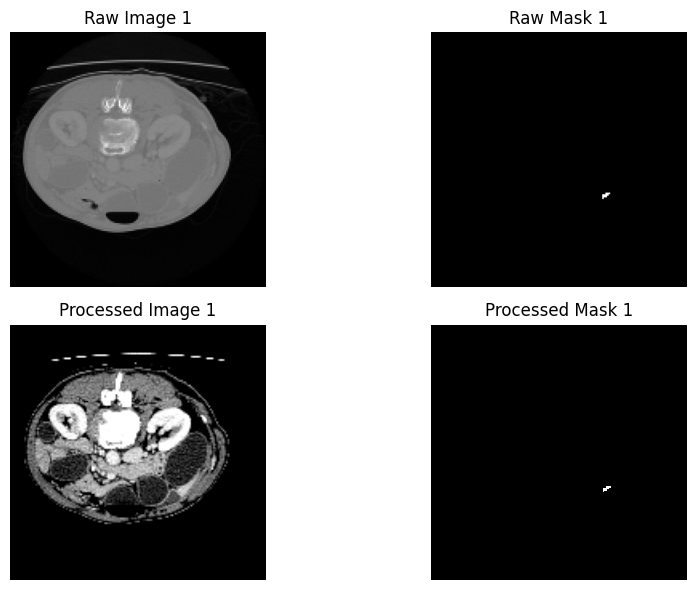

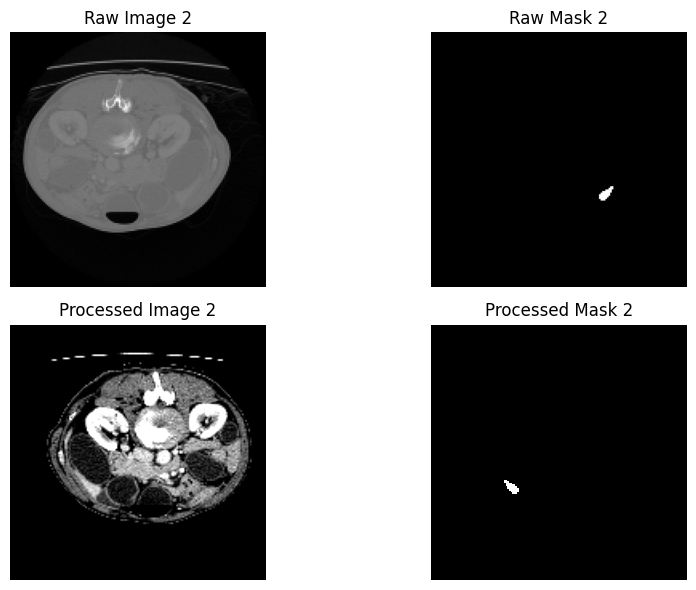

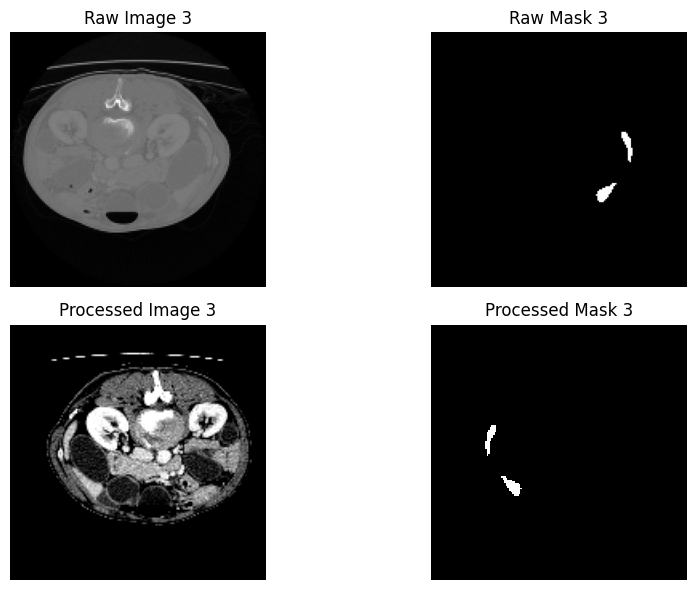

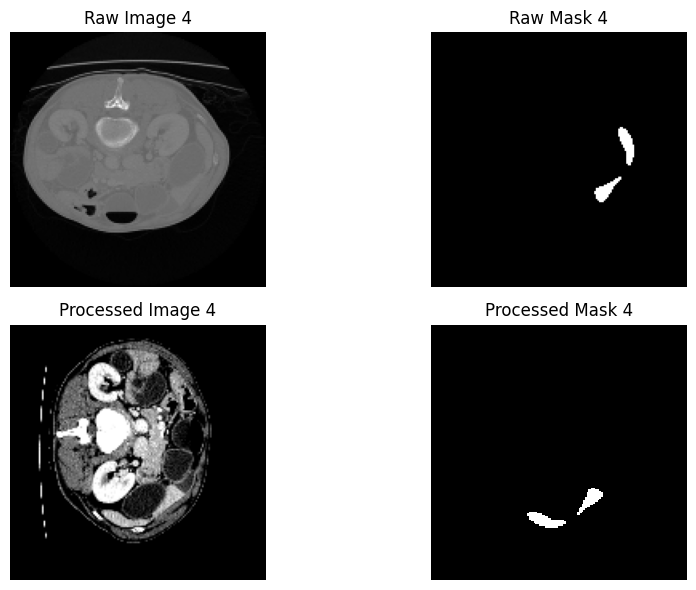

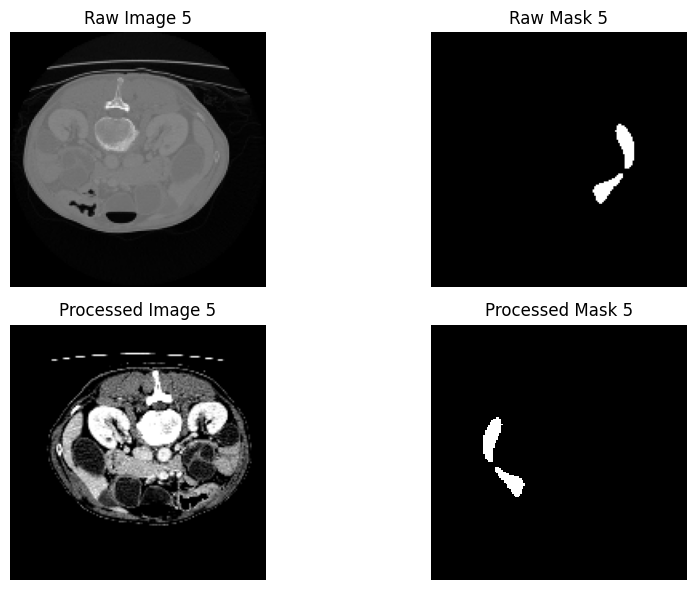


Done! Displayed 5 liver-containing slices.



In [18]:
num_samples = 5
print(f"\nDisplaying {num_samples} samples WITH liver only...\n")

count = 0   # how many liver slices we have shown
idx = 0     # dataframe index pointer

while count < num_samples and idx < len(train_df):

    sample_row = train_df.iloc[idx]

    if sample_row["liver_mask_exists"] == 1:

        # ---- 1. RAW DATA ----
        raw_img, raw_mask = load_raw_slice(sample_row)

        # ---- 2. PROCESSED DATA ----
        proc_img, proc_mask = train_dataset[idx]

        # Convert processed tensors → numpy HWC
        proc_img = proc_img.numpy().transpose(1, 2, 0)
        proc_mask = proc_mask.numpy().transpose(1, 2, 0)

        # ---- VISUALIZE ----
        visualize_sample(raw_img, raw_mask, proc_img, proc_mask, count + 1)

        count += 1  # only increment when liver slice is shown

    idx += 1

print(f"\nDone! Displayed {count} liver-containing slices.\n")

# **Importing Model**

In [19]:
from monai.networks.nets import UNet

model = UNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(32, 64, 128, 256, 512),
    strides=(2,2,2,2),
    num_res_units=2,
    act='PRELU',
    norm='INSTANCE',
    dropout=0.0,
    bias=True,
    adn_ordering='NDA'
).to(device)
from torchinfo import summary
summary(model, input_size=(1, 1, 256, 256), col_names=("input_size","output_size","num_params","trainable"), device=str(device))

Layer (type:depth-idx)                                                                     Input Shape               Output Shape              Param #                   Trainable
UNet                                                                                       [1, 1, 256, 256]          [1, 1, 256, 256]          --                        True
├─Sequential: 1-1                                                                          [1, 1, 256, 256]          [1, 1, 256, 256]          --                        True
│    └─ResidualUnit: 2-1                                                                   [1, 1, 256, 256]          [1, 32, 128, 128]         --                        True
│    │    └─Conv2d: 3-1                                                                    [1, 1, 256, 256]          [1, 32, 128, 128]         320                       True
│    │    └─Sequential: 3-2                                                                [1, 1, 256, 256]          [1, 32, 

# **Defining Metrics**

In [20]:
def compute_metrics(outputs, targets, threshold=0.5, eps=1e-7):
    """
    Returns soft-thresholded Dice, IoU, Precision, Recall (floats).
    outputs: raw logits (Tensor Bx1xHxW)
    targets: binary masks  (Tensor Bx1xHxW)
    """
    probs       = torch.sigmoid(outputs)
    preds       = (probs > threshold).float()
    t_flat      = targets.view(targets.size(0), -1)
    p_flat      = preds.view(preds.size(0), -1)

    tp    = (p_flat * t_flat).sum(dim=1)
    fp    = p_flat.sum(dim=1) - tp
    fn    = t_flat.sum(dim=1) - tp

    dice  = (2*tp + eps) / (p_flat.sum(1) + t_flat.sum(1) + eps)
    iou   = (tp + eps)   / (p_flat.sum(1) + t_flat.sum(1) - tp + eps)
    prec  = (tp + eps)   / (tp + fp + eps)
    rec   = (tp + eps)   / (tp + fn + eps)

    return dice.mean().item(), iou.mean().item(), prec.mean().item(), rec.mean().item()

In [21]:
def compute_hausdorff(outputs, targets, threshold=0.5, percentile=95):
    """
    Returns mean Hausdorff Distance over the batch.
    outputs: raw logits (Tensor Bx1xHxW)
    targets: binary masks  (Tensor Bx1xHxW)
    """
    probs = torch.sigmoid(outputs)
    preds = (probs > threshold).float()
    hd_metric = HausdorffDistanceMetric(include_background=False, percentile=percentile)
    # hd_metric accepts batch‐first torch.Tensors directly
    hd_vals = hd_metric(preds, targets)
    # hd_vals is Tensor of shape (B,)
    return float(torch.nanmean(hd_vals).item())

# **Loss Function**

In [22]:
dice_loss = DiceLoss(include_background=False, to_onehot_y=False, sigmoid=True)
bce_loss = nn.BCEWithLogitsLoss()

def criterion(outputs, targets):
    dice = dice_loss(outputs, targets)
    bce  = bce_loss(outputs, targets)
    return config.alpha * dice + config.beta * bce

In [23]:
inputs, masks = next(iter(train_loader))
inputs = inputs.to(device)
outputs = model(inputs)
print(inputs.shape, outputs.shape, masks.shape)

torch.Size([16, 1, 256, 256]) torch.Size([16, 1, 256, 256]) torch.Size([16, 1, 256, 256])


# **Training and Validation Loop**

In [24]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
optimizer = torch.optim.AdamW(model.parameters(), lr=Config.lr, weight_decay=1e-4)

scheduler = ReduceLROnPlateau(
    optimizer, 
    mode = 'min',
    factor=0.5       
)

In [25]:
class Trainer:

    def __init__(self,
                 model,
                 train_loader,
                 val_loader,
                 optimizer,
                 scheduler,
                 device,
                 criterion,
                 compute_metrics,
                 compute_hausdorff,
                 csv_path="training_log.csv",
                 checkpoint_path="best_model.pth",
                 patience=10):

        # Core components
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device

        # Loss & metric functions
        self.criterion = criterion
        self.compute_metrics = compute_metrics
        self.compute_hausdorff = compute_hausdorff

        # Logging
        self.csv_path = csv_path
        self.checkpoint_path = checkpoint_path
        self.patience = patience

        # Tracking
        self.best_val_loss = float('inf')
        self.patience_counter = 0

        # CSV header
        self.fields = [
            "epoch", "time",
            "train_loss", "val_loss",
            "dice_train", "dice_val",
            "iou_train", "iou_val",
            "precision_train", "precision_val",
            "recall_train", "recall_val",
            "hd_train", "hd_val",
            "lr"
        ]

        self._create_csv()


    def _create_csv(self):
        with open(self.csv_path, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=self.fields)
            writer.writeheader()

    def _append_csv(self, row_dict):
        with open(self.csv_path, "a", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=self.fields)
            writer.writerow(row_dict)

    # ---------------------------------------------------
    # TRAIN ONE EPOCH
    # ---------------------------------------------------
    def _train_one_epoch(self, epoch):

        import math

        self.model.train()
        t_loss = t_dice = t_iou = t_prec = t_rec = 0.0
        t_hd = 0.0  # accumulate batch-wise HD95

        train_iter = tqdm(enumerate(self.train_loader),
                          total=len(self.train_loader),
                          desc=f"Epoch {epoch} [Train]")

        for i, (data, labels) in train_iter:

            data = data.to(self.device)
            labels = labels.to(self.device).float()

            self.optimizer.zero_grad()

            outputs = self.model(data)
            if isinstance(outputs, (list, tuple)):
                outputs = outputs[-1]

            loss = self.criterion(outputs, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()

            # Loss accumulation
            t_loss += loss.item()

            # GPU metrics (Dice/IoU/Prec/Rec)
            b_dice, b_iou, b_prec, b_rec = self.compute_metrics(
                outputs.detach(), labels.detach()
            )

            t_dice += b_dice
            t_iou  += b_iou
            t_prec += b_prec
            t_rec  += b_rec

            # Compute batch HD95 on CPU and accumulate (constant memory)
            try:
                if labels.sum() > 0:
                    batch_hd = self.compute_hausdorff(outputs.cpu(), labels.cpu())
                else:
                    batch_hd = 0.0
            except Exception:
                # In case the metric function errors for this batch, treat as 0
                batch_hd = 0.0

            # Guard against NaN/inf: treat as 0 (empty masks -> correct prediction)
            if not isinstance(batch_hd, float) or not math.isfinite(batch_hd):
                batch_hd = 0.0

            t_hd += batch_hd

            # update progress (show averaged metrics so far)
            train_iter.set_postfix({
                "loss": f"{t_loss/(i+1):.4f}",
                "dice": f"{t_dice/(i+1):.4f}",
                "iou": f"{t_iou/(i+1):.4f}",
                "prec": f"{t_prec/(i+1):.4f}",
                "rec": f"{t_rec/(i+1):.4f}",
                "hd":   f"{(t_hd/(i+1)):.4f}"
            })

        n = len(self.train_loader)
        hd_train = t_hd / n if n > 0 else 0.0
        return (t_loss/n, t_dice/n, t_iou/n, t_prec/n, t_rec/n, hd_train)

    # ---------------------------------------------------
    # VALIDATION
    # ---------------------------------------------------
    def _validate(self, epoch):

        import math

        self.model.eval()
        v_loss = v_dice = v_iou = v_prec = v_rec = 0.0
        v_hd = 0.0

        val_iter = tqdm(enumerate(self.val_loader),
                        total=len(self.val_loader),
                        desc=f"Epoch {epoch} [Val]")

        with torch.no_grad():
            for i, (data, labels) in val_iter:

                data = data.to(self.device)
                if labels.ndim == 3:
                    labels = labels.unsqueeze(1)
                labels = labels.to(self.device).float()

                outputs = self.model(data)
                if isinstance(outputs, (list, tuple)):
                    outputs = outputs[-1]

                loss = self.criterion(outputs, labels)

                v_loss += loss.item()

                # GPU metrics
                b_dice, b_iou, b_prec, b_rec = self.compute_metrics(
                    outputs.detach(), labels.detach()
                )

                v_dice += b_dice
                v_iou  += b_iou
                v_prec += b_prec
                v_rec  += b_rec

                # batch-wise HD95 on CPU
                try:
                    batch_hd = self.compute_hausdorff(outputs.detach().cpu(), labels.detach().cpu())
                except Exception:
                    batch_hd = 0.0

                if not isinstance(batch_hd, float) or not math.isfinite(batch_hd):
                    batch_hd = 0.0

                v_hd += batch_hd

                val_iter.set_postfix({
                    "loss": f"{v_loss/(i+1):.4f}",
                    "dice": f"{v_dice/(i+1):.4f}",
                    "iou": f"{v_iou/(i+1):.4f}",
                    "prec": f"{v_prec/(i+1):.4f}",
                    "rec": f"{v_rec/(i+1):.4f}",
                    "hd":   f"{(v_hd/(i+1)):.4f}"
                })

        n = len(self.val_loader)
        hd_val = v_hd / n if n > 0 else 0.0
        return (v_loss/n, v_dice/n, v_iou/n, v_prec/n, v_rec/n, hd_val)

    # ---------------------------------------------------
    # MAIN TRAIN FUNCTION
    # ---------------------------------------------------
    def fit(self, num_epochs):

        total_time = 0

        for epoch in range(1, num_epochs+1):

            print(f"\n========== Epoch {epoch}/{num_epochs} ==========")
            start = time.time()

            # ---- training ----
            train_loss, train_dice, train_iou, train_prec, train_rec, train_hd = \
                self._train_one_epoch(epoch)

            # ---- validation ----
            val_loss, val_dice, val_iou, val_prec, val_rec, val_hd = \
                self._validate(epoch)

            # ---- scheduler ----
            self.scheduler.step(val_loss)
            lr = self.optimizer.param_groups[0]["lr"]

            epoch_time = time.time() - start
            total_time += epoch_time

            print(
                f"Train Loss={train_loss:.4f} | Dice={train_dice:.4f}, IoU={train_iou:.4f}, "
                f"Prec={train_prec:.4f}, Rec={train_rec:.4f}, HD={train_hd:.4f}"
            )
            print(
                f"Val   Loss={val_loss:.4f} | Dice={val_dice:.4f}, IoU={val_iou:.4f}, "
                f"Prec={val_prec:.4f}, Rec={val_rec:.4f}, HD={val_hd:.4f}"
            )

            # ---- checkpoint ----
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.patience_counter = 0
                torch.save(self.model.state_dict(), self.checkpoint_path)
                print("  ↳ Best model updated")
            else:
                self.patience_counter += 1
                print(f"  ↳ No improvement for {self.patience_counter} epoch(s)")
                if self.patience_counter >= self.patience:
                    print("Early stopping activated!")
                    break

            # ---- log to CSV ----
            self._append_csv({
                "epoch": epoch,
                "time": round(epoch_time, 2),
                "train_loss": round(train_loss, 4),
                "val_loss": round(val_loss, 4),
                "dice_train": round(train_dice, 4),
                "dice_val": round(val_dice, 4),
                "iou_train": round(train_iou, 4),
                "iou_val": round(val_iou, 4),
                "precision_train": round(train_prec, 4),
                "precision_val": round(val_prec, 4),
                "recall_train": round(train_rec, 4),
                "recall_val": round(val_rec, 4),
                "hd_train": round(train_hd, 4),
                "hd_val": round(val_hd, 4),
                "lr": lr
            })

        print(f"\nTraining Completed! Total Time = {total_time:.2f}s")
        print(f"Best Validation Loss = {self.best_val_loss:.4f}")
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    criterion=criterion,
    compute_metrics=compute_metrics,
    compute_hausdorff=compute_hausdorff,
    csv_path="Unet_metrics.csv",
    checkpoint_path="Unet_best.pth",
    patience=20
)

trainer.fit(num_epochs=config.num_epochs)


========== Epoch 1/50 ==========


Epoch 1 [Train]:   0%|          | 0/855 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/monai/losses/dice.py:175: UserWarning: single channel prediction, `include_background=False` ignored.
  warnings.warn("single channel prediction, `include_background=False` ignored.")
/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/usr/local/lib/python3.12/dist-packages/monai/metrics/utils.py:327: UserWarning: the ground truth of class 0 is all 0, this may result in nan/inf distance.
  warnings.warn(
Epoch 1 [Val]: 100%|██████████| 180/180 [00:51<00:00,  3.48it/s, loss=0.8459, dice=0.2101, iou=0.1763, prec=0.1789, rec=0.9639, hd=40.5095]

Train Loss=0.8622 | Dice=0.1624, IoU=0.1297, Prec=0.1326, Rec=0.9601, HD=115.2752
Val   Loss=0.8459 | Dice=0.2101, IoU=0.1763, Prec=0.1789, Rec=0.9639, HD=40.5095
  ↳ Best model updated

========== Epoch 2/50 ==========



Epoch 2 [Val]: 100%|██████████| 180/180 [00:45<00:00,  3.92it/s, loss=0.8268, dice=0.2357, iou=0.2085, prec=0.2167, rec=0.9378, hd=29.4288]


Train Loss=0.8380 | Dice=0.2129, IoU=0.1808, Prec=0.1872, Rec=0.9454, HD=76.1088
Val   Loss=0.8268 | Dice=0.2357, IoU=0.2085, Prec=0.2167, Rec=0.9378, HD=29.4288
  ↳ Best model updated

========== Epoch 3/50 ==========


...

Train Loss=0.4919 | Dice=0.8626, IoU=0.8486, Prec=0.8644, Rec=0.9816, HD=8.1639
Val   Loss=0.4995 | Dice=0.8878, IoU=0.8715, Prec=0.8964, Rec=0.9666, HD=8.4989
  ↳ No improvement for 3 epoch(s)

========== Epoch 49/50 ==========



Epoch 49 [Val]: 100%|██████████| 180/180 [00:30<00:00,  5.91it/s, loss=0.4990, dice=0.8326, iou=0.8147, prec=0.8351, rec=0.9715, hd=14.6265]

Train Loss=0.4920 | Dice=0.8579, IoU=0.8440, Prec=0.8589, Rec=0.9818, HD=8.1179
Val   Loss=0.4990 | Dice=0.8326, IoU=0.8147, Prec=0.8351, Rec=0.9715, HD=14.6265
  ↳ No improvement for 4 epoch(s)

========== Epoch 50/50 ==========



Epoch 50 [Val]: 100%|██████████| 180/180 [00:29<00:00,  6.09it/s, loss=0.4978, dice=0.8540, iou=0.8373, prec=0.8584, rec=0.9706, hd=12.2335]

Train Loss=0.4911 | Dice=0.8804, IoU=0.8666, Prec=0.8815, Rec=0.9824, HD=7.4526
Val   Loss=0.4978 | Dice=0.8540, IoU=0.8373, Prec=0.8584, Rec=0.9706, HD=12.2335
  ↳ No improvement for 5 epoch(s)

Training Completed! Total Time = 10143.50s
Best Validation Loss = 0.4967


# **Plotting the training and validation metrics**

   epoch    time  train_loss  val_loss  dice_train  dice_val  iou_train  \
0      1  321.23      0.8622    0.8459      0.1624    0.2101     0.1297   
1      2  283.45      0.8380    0.8268      0.2129    0.2357     0.1808   
2      3  253.78      0.8182    0.8103      0.2285    0.2215     0.1996   
3      4  213.19      0.7981    0.7859      0.2363    0.2531     0.2091   
4      5  217.24      0.7769    0.7647      0.2427    0.2577     0.2169   

   iou_val  precision_train  precision_val  recall_train  recall_val  \
0   0.1763           0.1326         0.1789        0.9601      0.9639   
1   0.2085           0.1872         0.2167        0.9454      0.9378   
2   0.1890           0.2097         0.2011        0.9423      0.9347   
3   0.2250           0.2201         0.2297        0.9463      0.9641   
4   0.2333           0.2286         0.2407        0.9492      0.9576   

   hd_train   hd_val      lr  
0  115.2752  40.5095  0.0001  
1   76.1088  29.4288  0.0001  
2   57.0042  33.5633  0

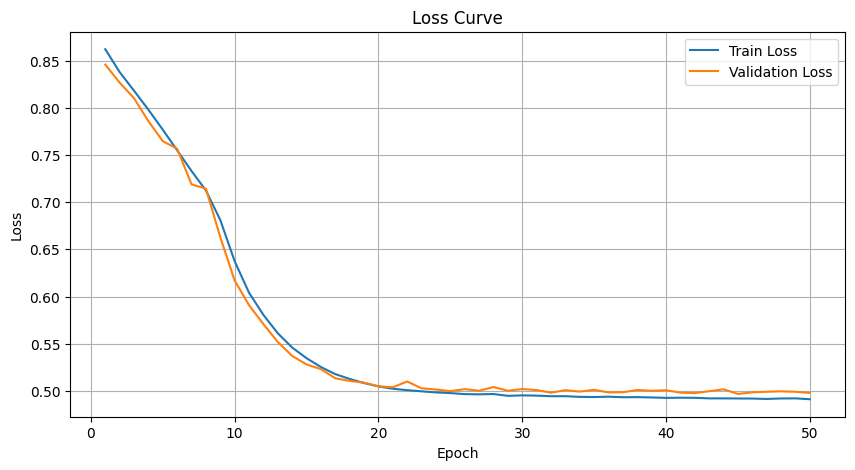

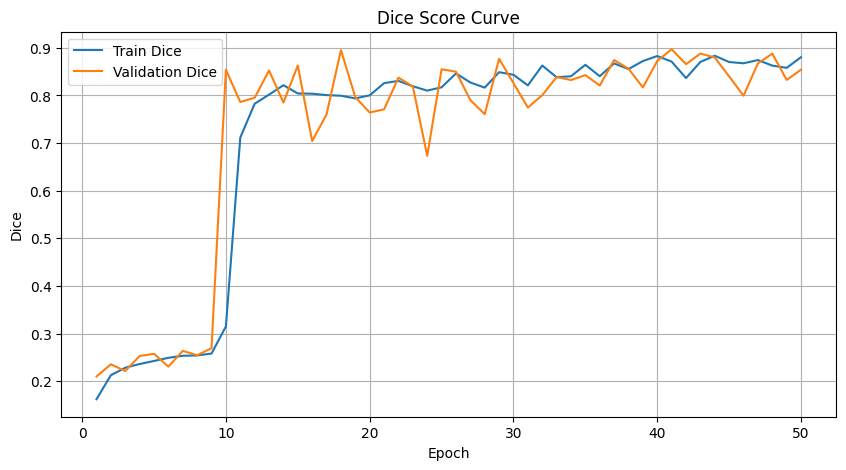

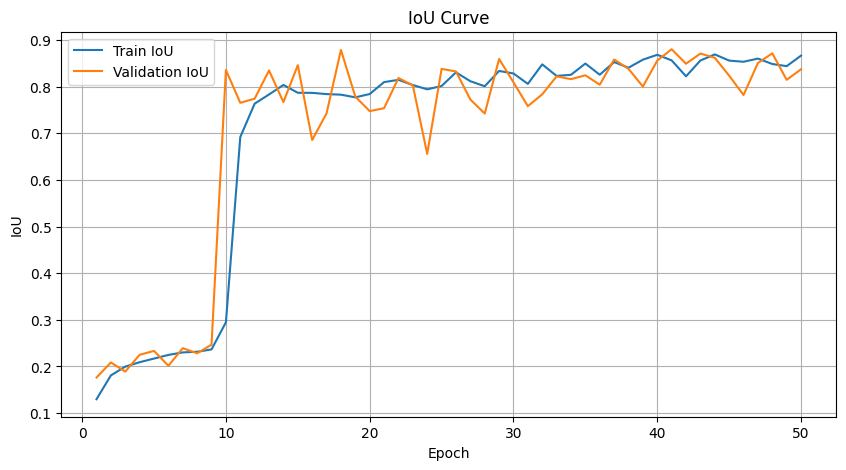

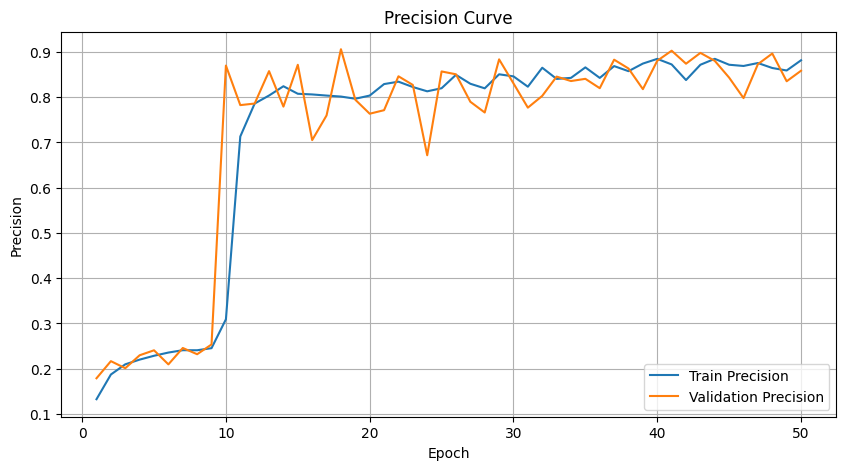

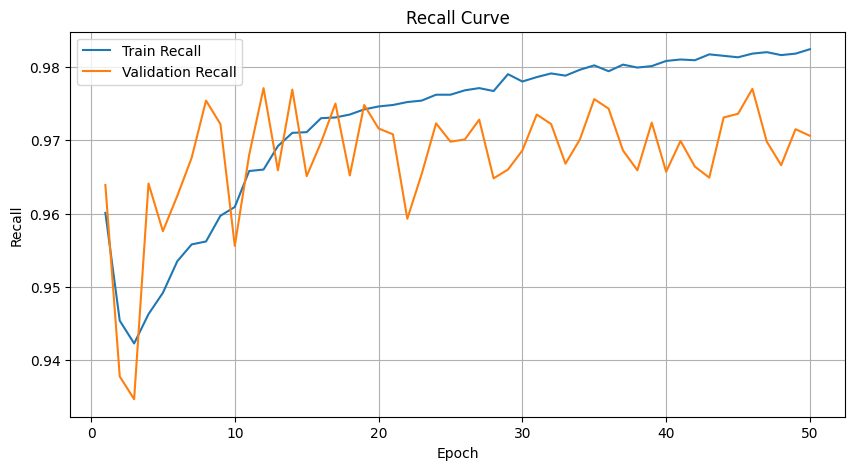

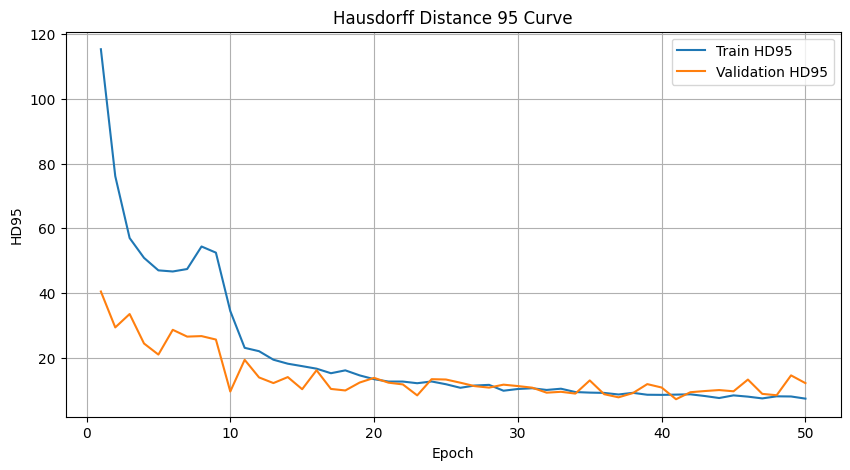

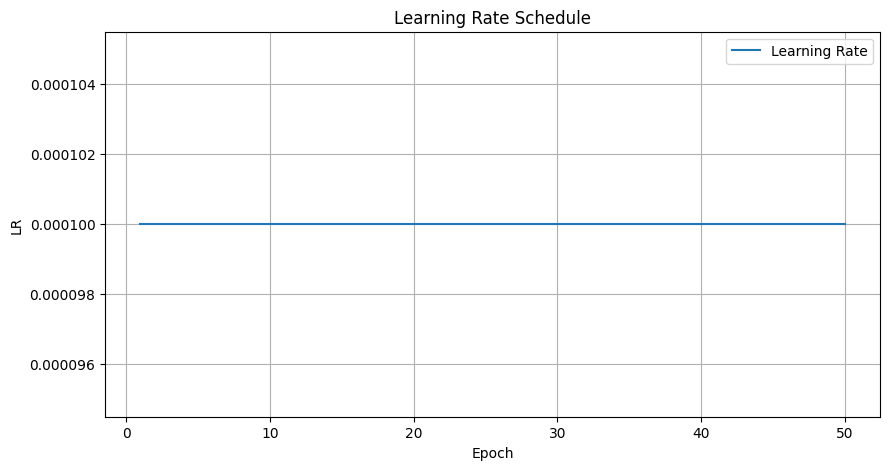

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your CSV file
# csv_path = "/kaggle/input/unetmetricsdice/Unet_metrics.csv"
csv_path = "Unet_metrics.csv"
df = pd.read_csv(csv_path)
print(df.head())

# Helper function to plot curves
def plot_curve(df, column_train, column_val, title, ylabel):
    plt.figure(figsize=(10,5))
    plt.plot(df['epoch'], df[column_train], label=f"Train {ylabel}")
    plt.plot(df['epoch'], df[column_val], label=f"Validation {ylabel}")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

# ---- Plot all metrics ----

# Loss
plot_curve(df, "train_loss", "val_loss", "Loss Curve", "Loss")

# Dice
plot_curve(df, "dice_train", "dice_val", "Dice Score Curve", "Dice")

# mIoU
plot_curve(df, "iou_train", "iou_val", "IoU Curve", "IoU")

# Precision
plot_curve(df, "precision_train", "precision_val", "Precision Curve", "Precision")

# Recall
plot_curve(df, "recall_train", "recall_val", "Recall Curve", "Recall")

# HD95
plot_curve(df, "hd_train", "hd_val", "Hausdorff Distance 95 Curve", "HD95")

# Learning Rate
plt.figure(figsize=(10,5))
plt.plot(df['epoch'], df['lr'], label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.title("Learning Rate Schedule")
plt.grid()
plt.legend()
plt.show()

# **Inference**

In [27]:
import math
from matplotlib.patches import Patch


model = UNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(32, 64, 128, 256, 512),
    strides=(2, 2, 2, 2),
    num_res_units=2
).to(device)

model.load_state_dict(torch.load(
    "/kaggle/working/Unet_best.pth",
    map_location=device
))
model.eval()

all_dice, all_iou, all_prec, all_rec, all_hd = [], [], [], [], []


with torch.no_grad():
    for batch_img, batch_mask in test_loader:

        batch_img = batch_img.to(device)
        batch_mask = batch_mask.to(device)

        logits = model(batch_img)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        b_dice, b_iou, b_prec, b_rec = compute_metrics(
            logits.detach(), batch_mask.detach()
        )

        all_dice.append(b_dice)
        all_iou.append(b_iou)
        all_prec.append(b_prec)
        all_rec.append(b_rec)

        try:
            hd_batch = compute_hausdorff(
                logits.detach().cpu(), batch_mask.detach().cpu()
            )
        except:
            hd_batch = 0.0

        if not isinstance(hd_batch, float) or not math.isfinite(hd_batch):
            hd_batch = 0.0

        all_hd.append(hd_batch)


print("\n================= FINAL VALIDATION METRICS =================")
print(f"Dice Score: {np.mean(all_dice):.4f}")
print(f"IoU (mIoU): {np.mean(all_iou):.4f}")
print(f"Precision:  {np.mean(all_prec):.4f}")
print(f"Recall:     {np.mean(all_rec):.4f}")
print(f"HD95:       {np.mean(all_hd):.4f}")
print("=============================================================\n")

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/usr/local/lib/python3.12/dist-packages/monai/metrics/utils.py:327: UserWarning: the ground truth of class 0 is all 0, this may result in nan/inf distance.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/monai/metrics/utils.py:332: UserWarning: the prediction of class 0 is all 0, this may result in nan/inf distance.
  warnings.warn(



================= FINAL VALIDATION METRICS =================
Dice Score: 0.8407
IoU (mIoU): 0.8219
Precision:  0.8442
Recall:     0.9671
HD95:       8.5177



# **Visualising the results**

In [28]:
def visualize(gt, pred, diff, idx):

    fig, axs = plt.subplots(1, 3, figsize=(20, 6))

    axs[0].imshow(gt, cmap="gray")
    axs[0].set_title("Ground Truth")
    axs[0].axis("off")

    axs[1].imshow(pred, cmap="gray")
    axs[1].set_title("Prediction")
    axs[1].axis("off")

    axs[2].imshow(diff)
    axs[2].set_title("Difference Map")
    axs[2].axis("off")

    legend_elements = [
        Patch(facecolor='green', edgecolor='green', label='TP (Correct)'),
        Patch(facecolor='red',   edgecolor='red',   label='FN (Missed GT)'),
        Patch(facecolor='blue',  edgecolor='blue',  label='FP (Extra Pred)')
    ]

    axs[2].legend(
        handles=legend_elements,
        loc='upper right',
        fontsize=12,
        framealpha=0.9
    )

    plt.tight_layout()
    plt.show()

Found 10 test samples with liver.


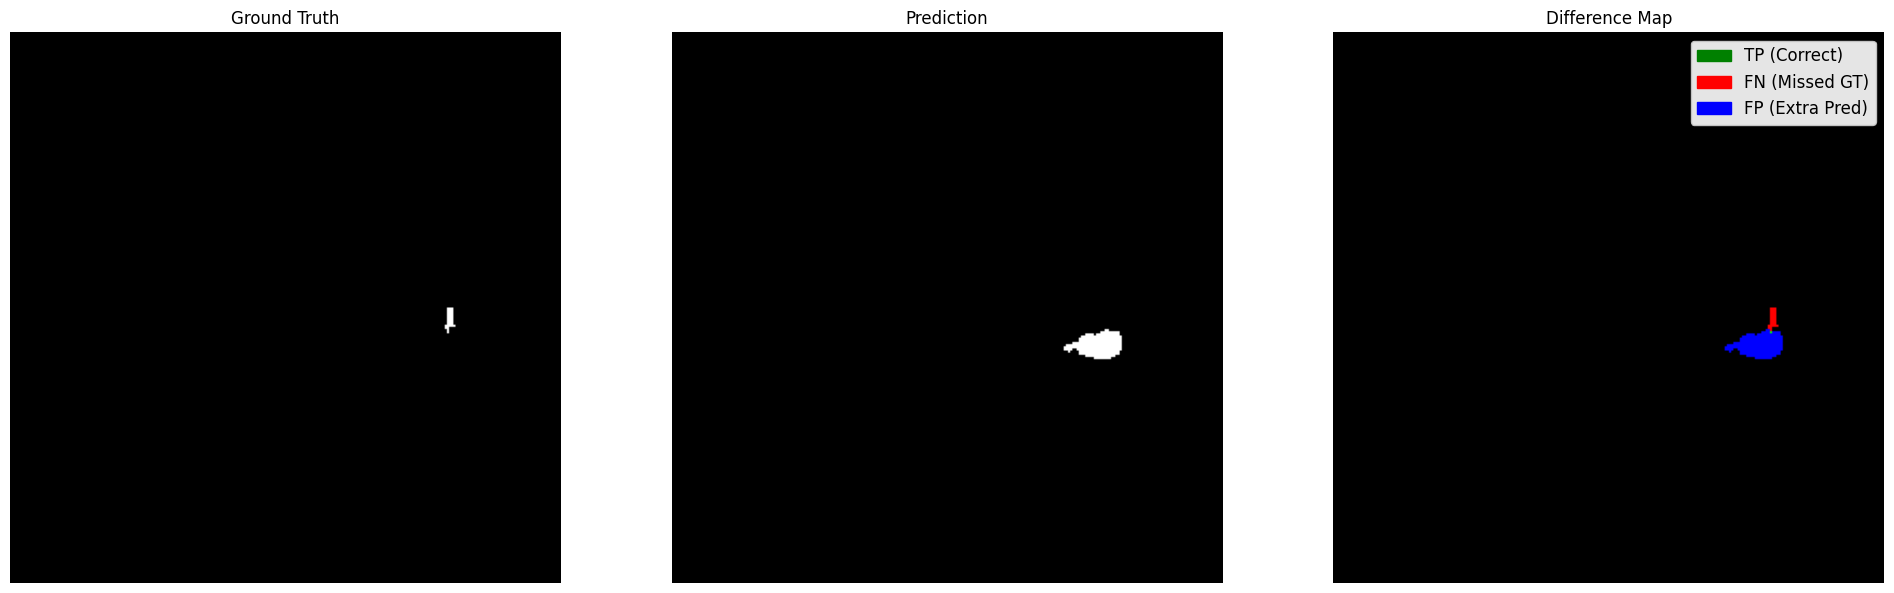

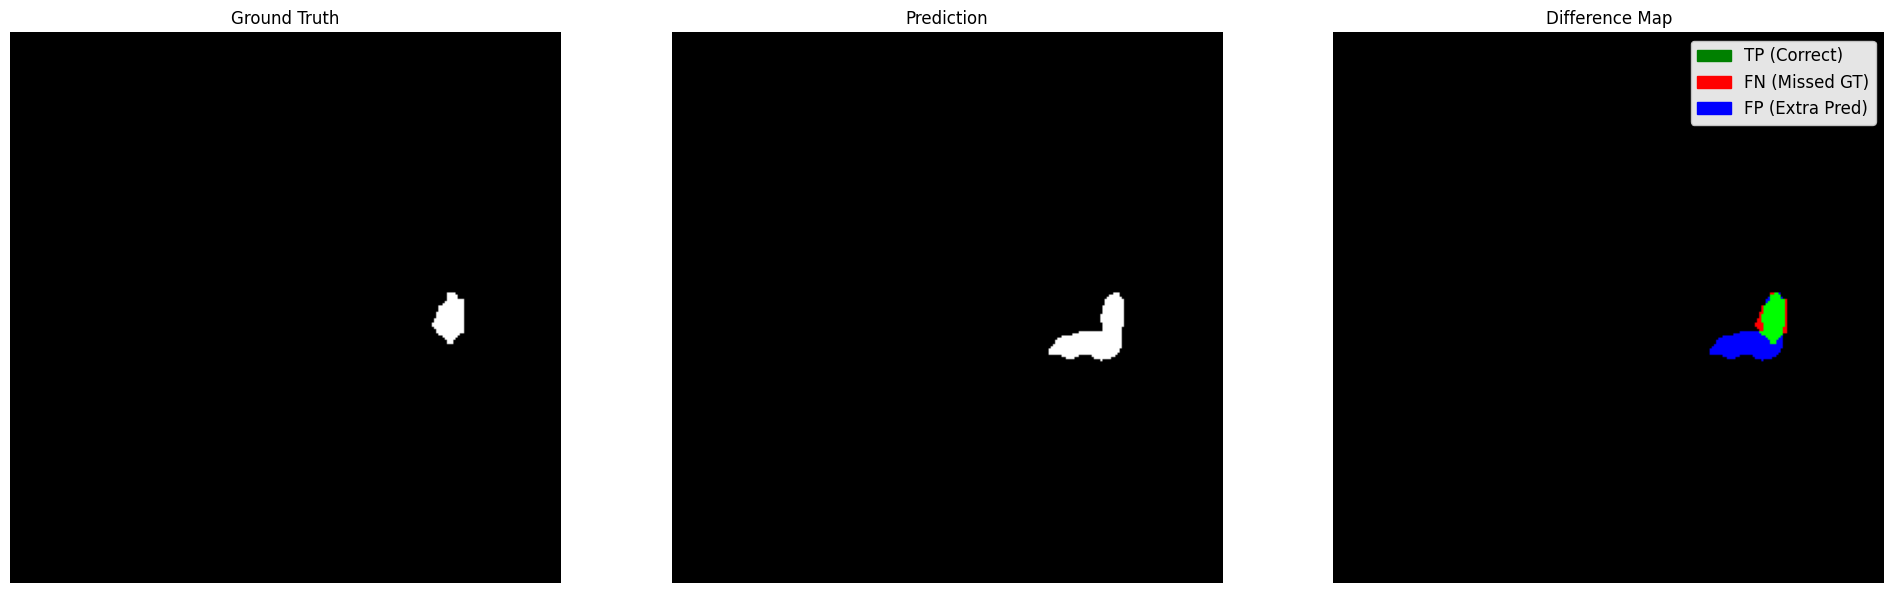

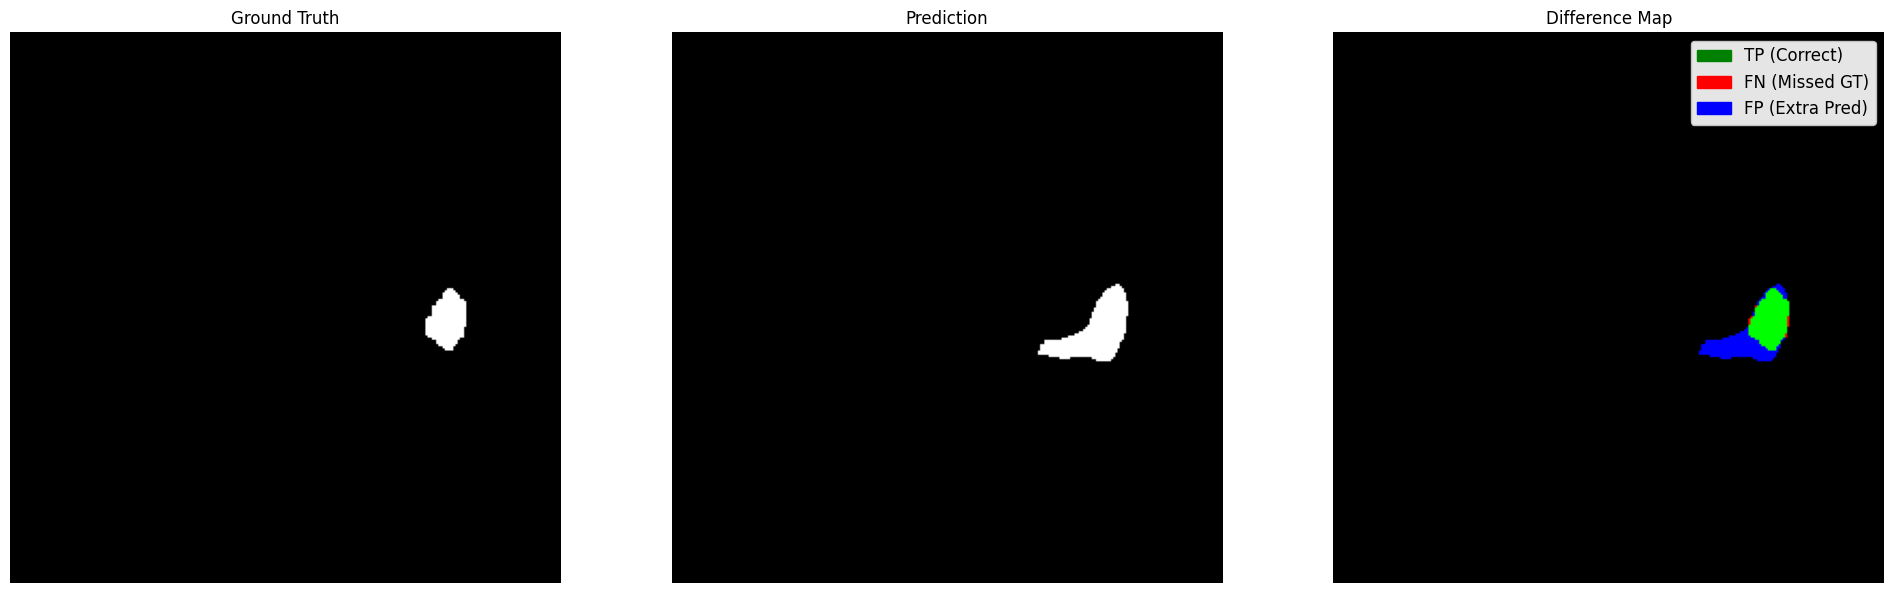

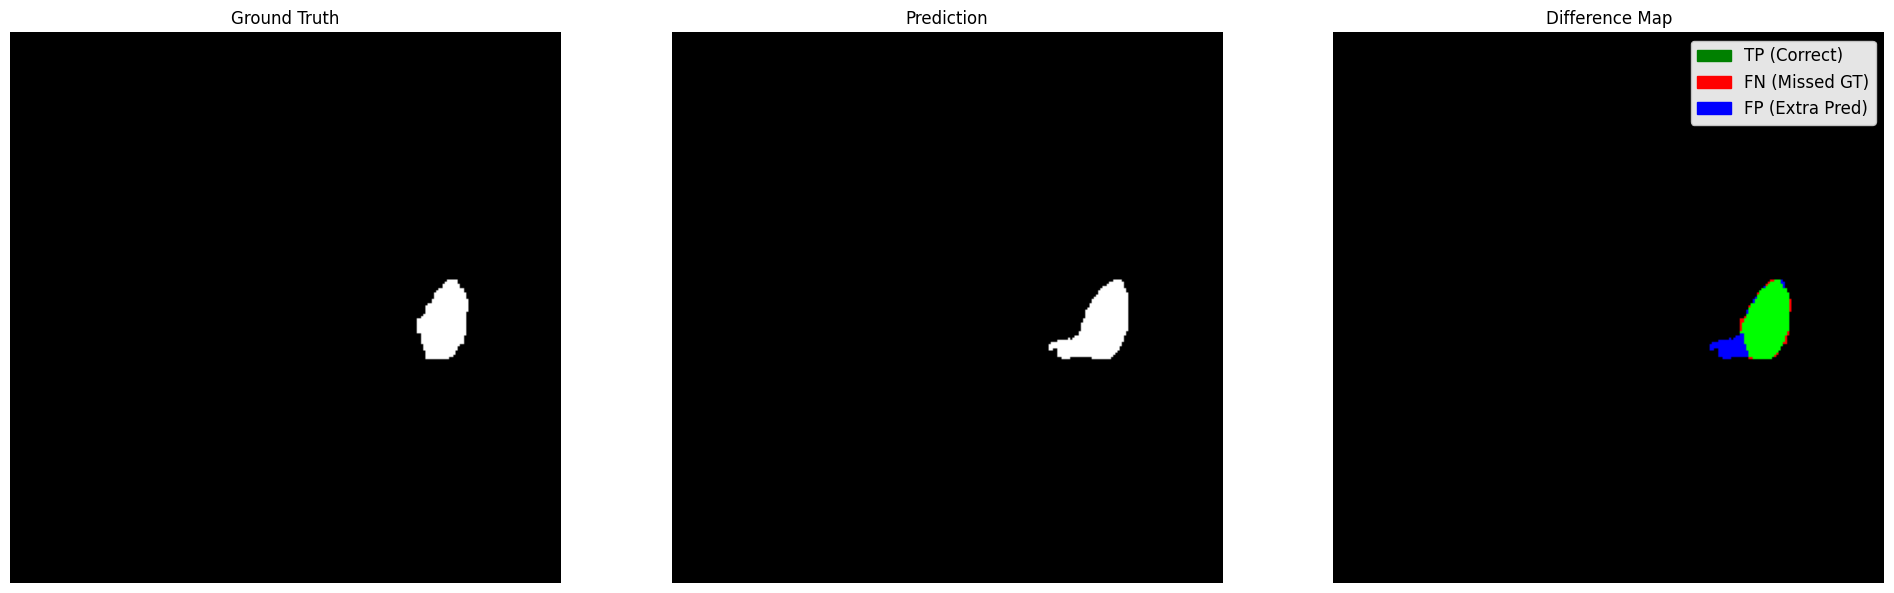

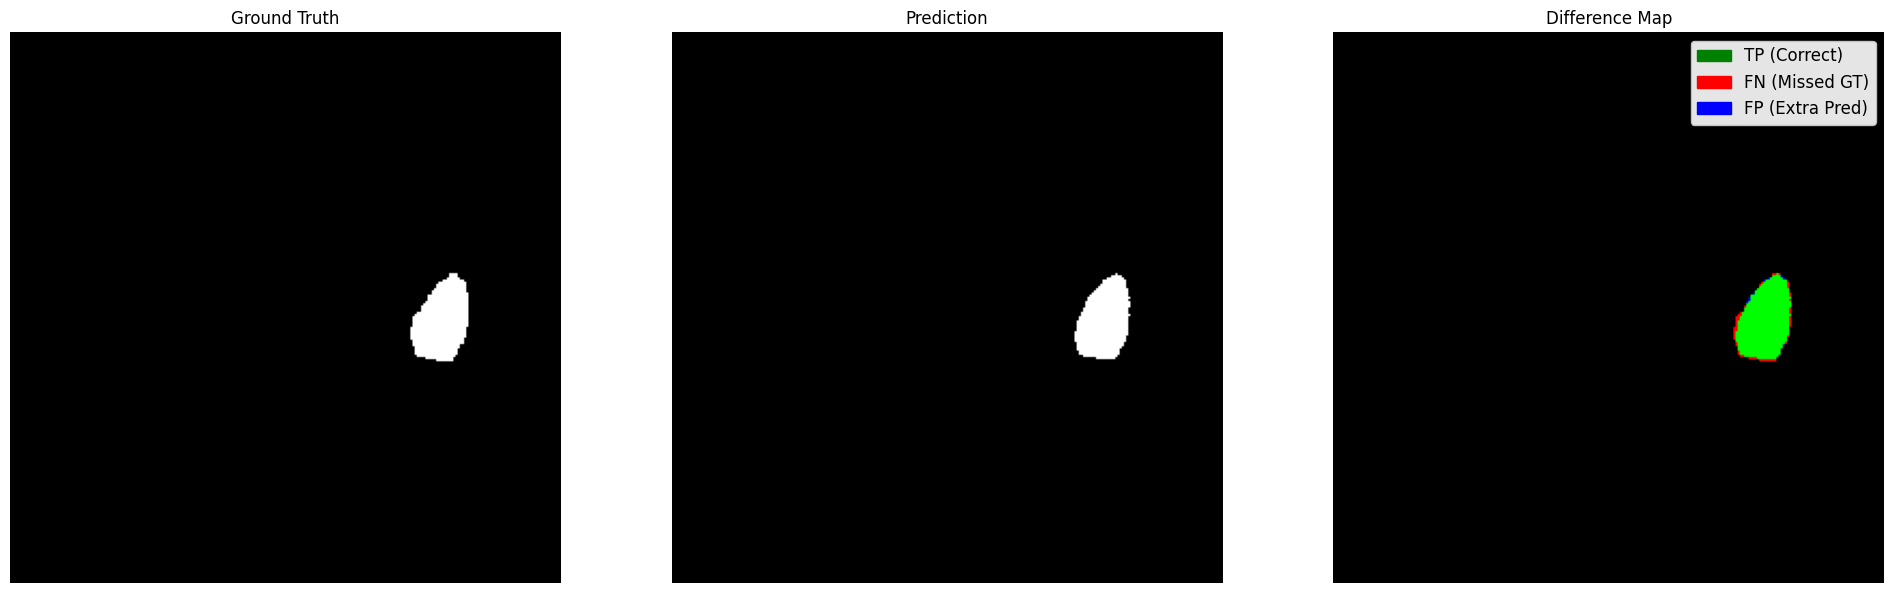

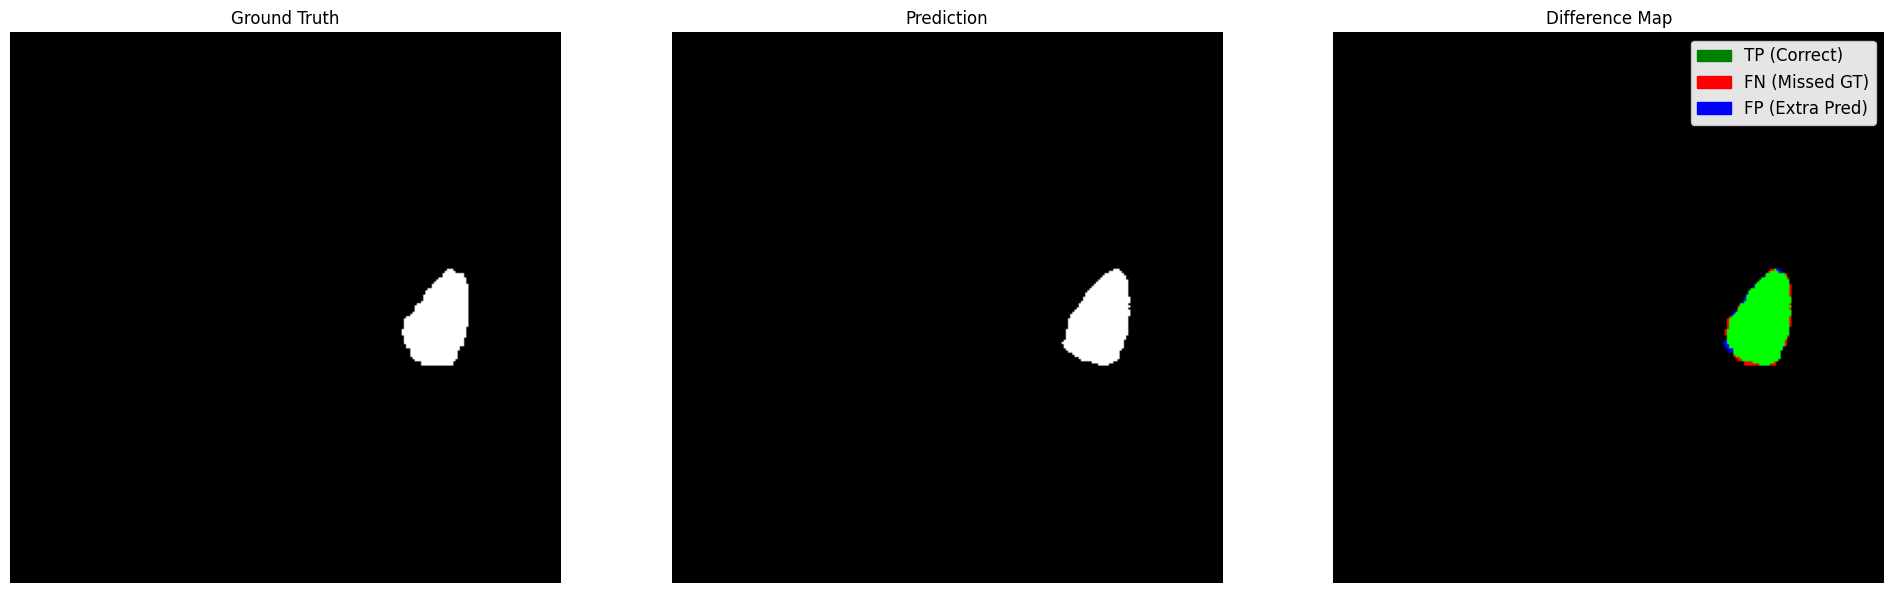

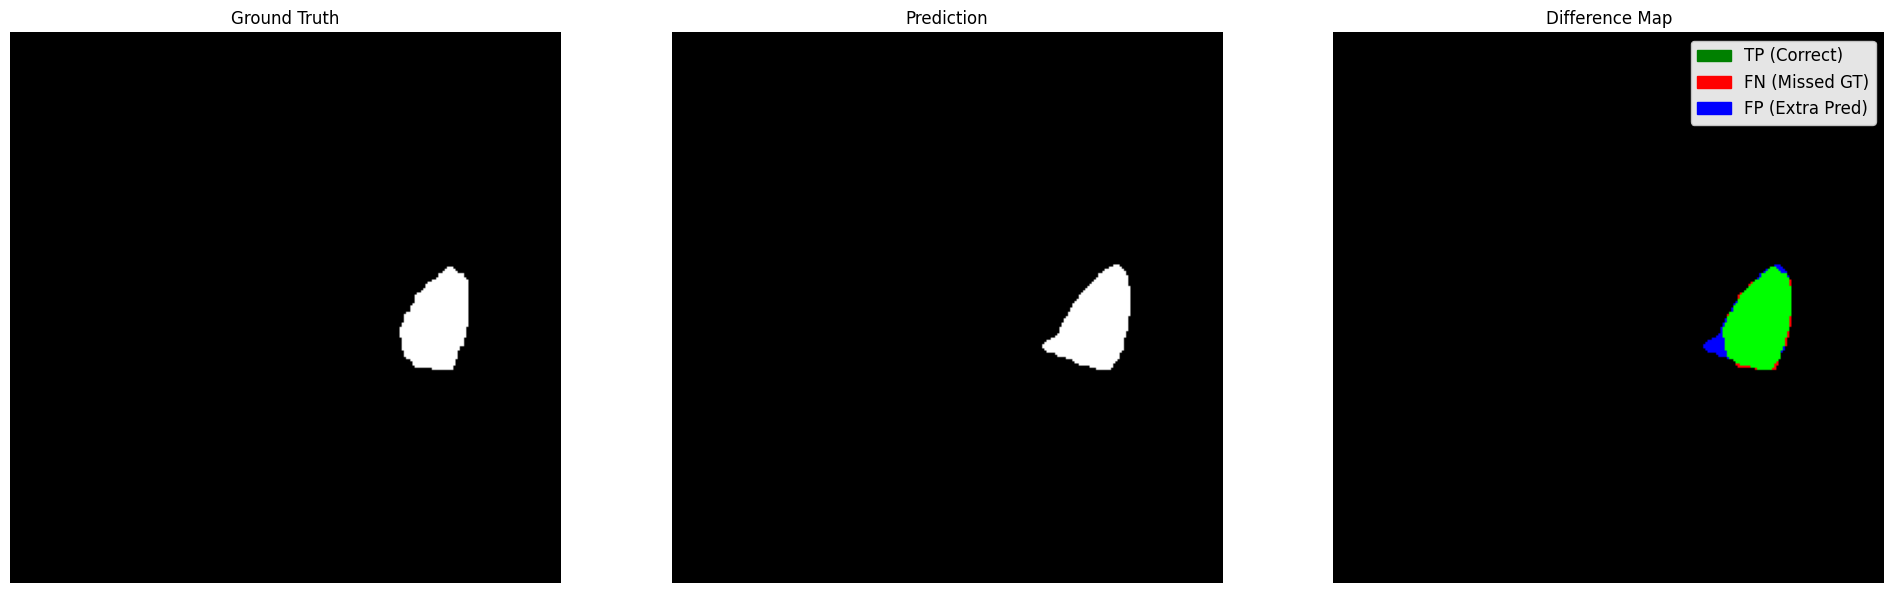

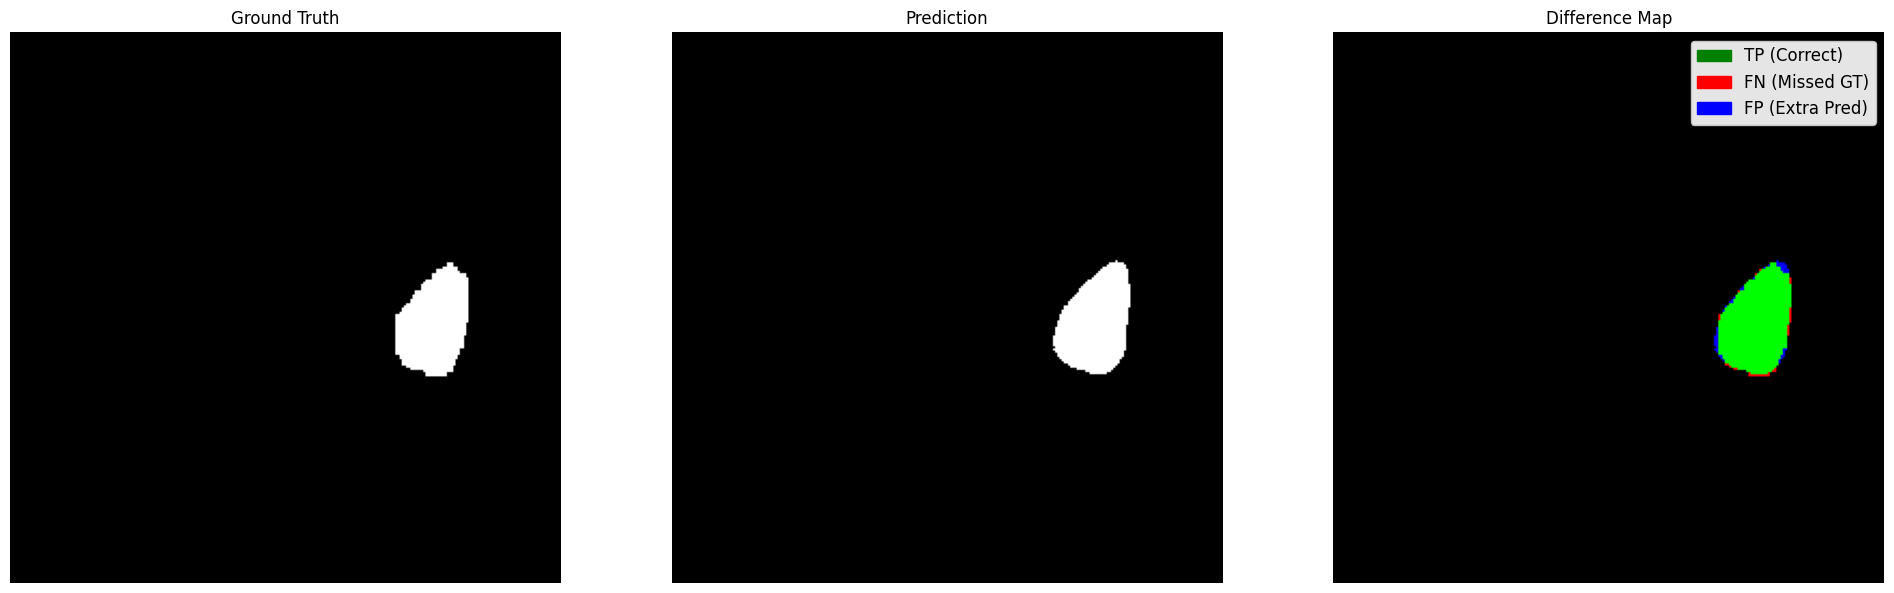

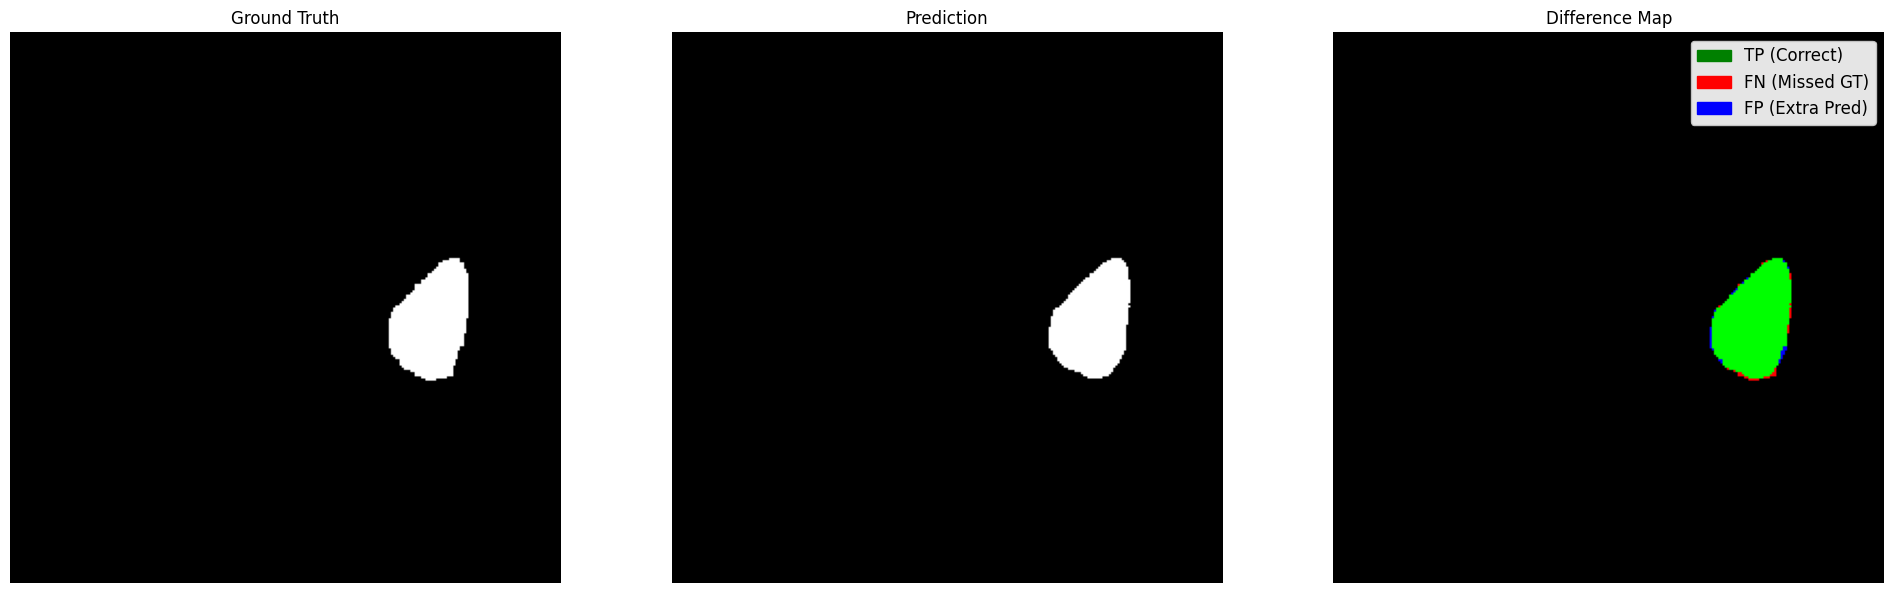

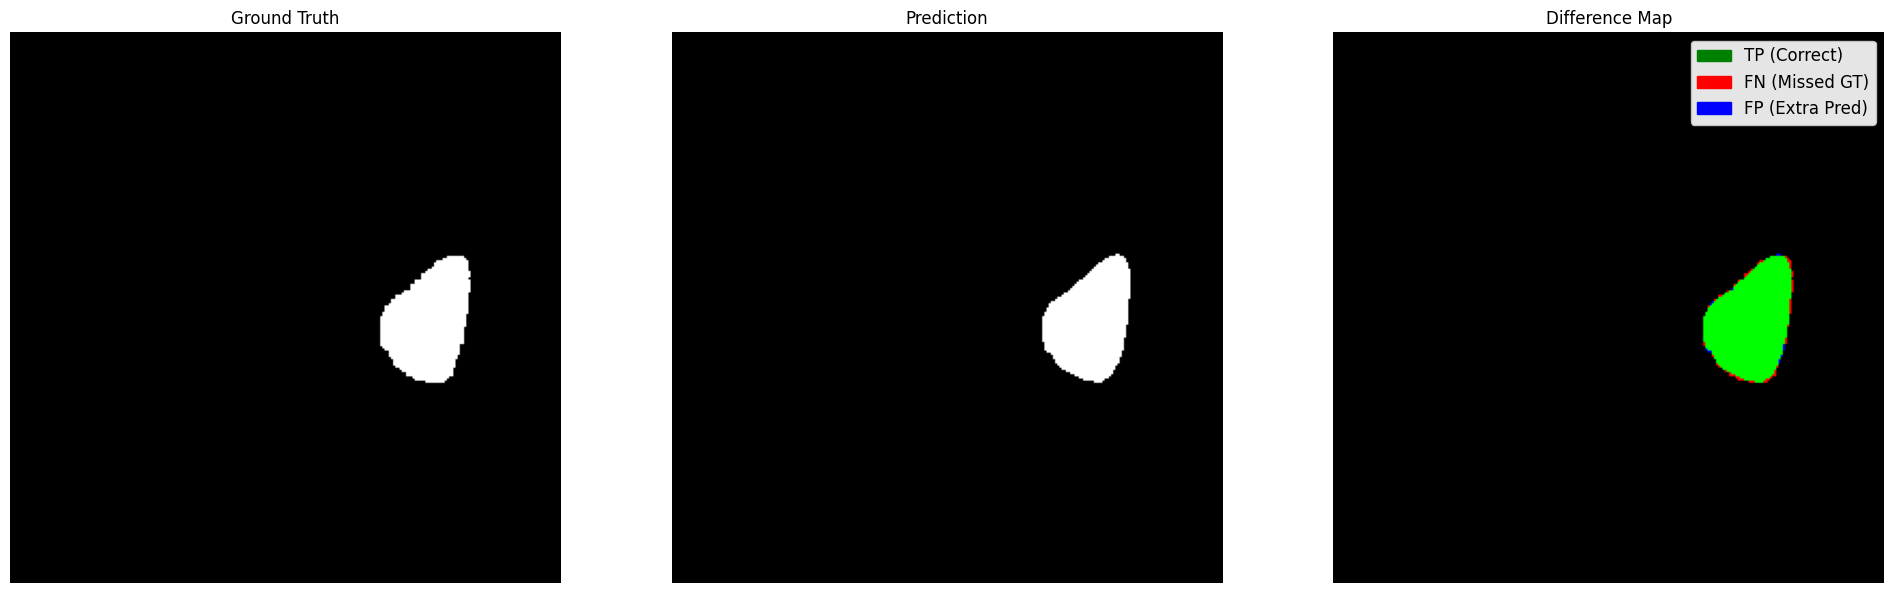

In [29]:
samples = []
for img, mask in test_loader:
    for i in range(img.shape[0]):
        if mask[i].sum().item() > 0:
            samples.append((img[i], mask[i]))
        if len(samples) >= 10:
            break
    if len(samples) >= 10:
        break

print(f"Found {len(samples)} test samples with liver.")


model.eval()
for idx, (img, mask) in enumerate(samples, 1):

    x = img.unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        prob = torch.sigmoid(logits)[0,0].cpu().numpy()
        pred = (prob > 0.5).astype(np.uint8)

    gt_vis = mask.numpy().squeeze()
    pred_vis = pred

    diff = np.zeros((gt_vis.shape[0], gt_vis.shape[1], 3), dtype=np.float32)

    diff[(gt_vis == 1) & (pred_vis == 1)] = [0, 1, 0]     # Green
    diff[(gt_vis == 1) & (pred_vis == 0)] = [1, 0, 0]     # Red
    diff[(gt_vis == 0) & (pred_vis == 1)] = [0, 0, 1]     # Blue

    visualize(gt_vis, pred_vis, diff, idx)